# Reference-like M1/M2/M3 Benchmarks

This notebook runs small, reference-like versions of the M1, M2, and M3 simulations against the current `weightederm` package. It includes both the fixed, known number of change points setting and the unknown number of change points setting. The main output is the normalized Hausdorff distance between the true and estimated changepoint locations, aggregated over the same `delta = n / p` grids used in the original experiments.

For M1 and M2, the notebook can also attempt an optional `McScan` comparison if that environment is available.

In [1]:
# ruff: noqa: E402
from dataclasses import replace
from pathlib import Path
import sys

import numpy as np

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from weightederm import WERMLeastSquaresCV, WERMLogisticCV
from weightederm._benchmark_examples import (
    plot_hausdorff_summary,
    plot_hausdorff_summary_with_percentiles,
    reference_like_benchmark_specs,
    run_benchmark,
    run_benchmark_unknown,
    simulate_trial,
    write_rows_to_csv,
)

OUTPUT_DIR = ROOT / "notebooks" / "results" / "reference_like_m123"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('/scratch/ga442/weightederm/notebooks/results/reference_like_m123')

## Optional McScan setup

This benchmark notebook keeps `McScan` optional. To run it, the interested user needs:

- Python package `rpy2`
- R package `inferchange`
- a working local R installation visible to the notebook kernel

Leave `INSTALL_MCSCAN_DEPS = False` for normal package use. If you flip it to `True`, the next cell installs the minimal extras for this notebook only. `inferchange` is installed from GitHub, which is the route used by the reference package.

In [2]:
INSTALL_MCSCAN_DEPS = False

if INSTALL_MCSCAN_DEPS:
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "rpy2"], check=True)
    subprocess.run(
        [
            "R",
            "-q",
            "-e",
            "install.packages('remotes', repos='https://cloud.r-project.org')",
        ],
        check=True,
    )
    subprocess.run(
        [
            "R",
            "-q",
            "-e",
            "remotes::install_github('tobiaskley/inferchange')",
        ],
        check=True,
    )
    print("If rpy2 was newly installed, restart the notebook kernel before running benchmarks.")

## Config

- `NUM_TRIALS = 30` matches the main reference sweeps more closely.
- Lower it to `5` or `10` for a quicker smoke run.
- `INCLUDE_MCSCAN = True` only affects the linear experiments M1 and M2.
- `LEAST_SQUARES_FIT_SOLVER` lets you compare `direct` vs `lbfgsb` on M1 and M2 for the fixed, known number of change points setting.
- `MCSCAN_MODE = "fixed"` matches the fixed, known number of change points benchmark setup.
- `M1_NOTEBOOK_DELTA_RATIOS` lifts the notebook M1 sweep into a more informative range for changepoint recovery.
- The unknown number of change points section below follows the reference behavior more closely by using `run_benchmark_unknown(...)`, which runs `McScan` in automatic mode for M1 and M2 when requested.

In [3]:
NUM_TRIALS = 30
INCLUDE_MCSCAN = False
LEAST_SQUARES_FIT_SOLVER = "direct"
MCSCAN_MODE = "fixed"
BASE_SEED = 42
M1_NOTEBOOK_DELTA_RATIOS = (1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0)
M2_NOTEBOOK_DELTA_RATIOS = (0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5)
M3_NOTEBOOK_DELTA_RATIOS = (1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0)

# Parallelism: set N_JOBS > 1 to run trials in parallel across CPUs.
# N_JOBS = -1 uses all available CPUs; N_JOBS = 1 runs serially (default).
N_JOBS = 36

specs = reference_like_benchmark_specs()
specs["M1"] = replace(specs["M1"], delta_ratios=M1_NOTEBOOK_DELTA_RATIOS)
specs["M2"] = replace(specs["M2"], delta_ratios=M2_NOTEBOOK_DELTA_RATIOS)
specs["M3"] = replace(specs["M3"], delta_ratios=M3_NOTEBOOK_DELTA_RATIOS)
specs

{'M1': ExperimentSpec(name='M1', p=200, num_signals=3, delta_ratios=(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0), fractional_chgpt_locations=(0.4, 0.7), delta_fraction=0.05),
 'M2': ExperimentSpec(name='M2', p=200, num_signals=4, delta_ratios=(0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5), fractional_chgpt_locations=(0.4, 0.7), delta_fraction=0.1),
 'M3': ExperimentSpec(name='M3', p=200, num_signals=2, delta_ratios=(1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0), fractional_chgpt_locations=(0.3333333333333333,), delta_fraction=0.05)}

## Fixed, known number of change points

This section runs the fixed-`num_chgpts` analogues of M1, M2, and M3. For M1 and M2, `LEAST_SQUARES_FIT_SOLVER` lets you compare the fast direct least-squares solver against the slower `lbfgsb` path.

In [4]:
all_trial_rows = []
all_summary_rows = []

for experiment_name in ("M1", "M2", "M3"):
    trial_rows, summary_rows = run_benchmark(
        specs[experiment_name],
        num_trials=NUM_TRIALS,
        include_mcscan=INCLUDE_MCSCAN,
        least_squares_fit_solver=LEAST_SQUARES_FIT_SOLVER,
        mcscan_mode=MCSCAN_MODE,
        base_seed=BASE_SEED,
        n_jobs=N_JOBS,
    )
    all_trial_rows.extend(trial_rows)
    all_summary_rows.extend(summary_rows)
    write_rows_to_csv(trial_rows, OUTPUT_DIR / f"{experiment_name.lower()}_trial_rows.csv")
    write_rows_to_csv(summary_rows, OUTPUT_DIR / f"{experiment_name.lower()}_summary_rows.csv")
    print(experiment_name)
    for row in summary_rows:
        print(row)
    print()

write_rows_to_csv(all_trial_rows, OUTPUT_DIR / "all_trial_rows.csv")
write_rows_to_csv(all_summary_rows, OUTPUT_DIR / "all_summary_rows.csv")
OUTPUT_DIR

M1
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 1.0, 'mean_hausdorff': 0.40199999999999997, 'median_hausdorff': 0.37, 'p25_hausdorff': 0.355, 'p75_hausdorff': 0.395, 'num_trials': 30, 'mean_predicted_num_chgpts': 2.0, 'median_predicted_num_chgpts': 2.0, 'p25_predicted_num_chgpts': 2.0, 'p75_predicted_num_chgpts': 2.0, 'num_infinite_hausdorff': 0, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 30}
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 2.0, 'mean_hausdorff': 0.10250000000000001, 'median_hausdorff': 0.09625, 'p25_hausdorff': 0.08, 'p75_hausdorff': 0.12687500000000002, 'num_trials': 30, 'mean_predicted_num_chgpts': 2.0, 'median_predicted_num_chgpts': 2.0, 'p25_predicted_num_chgpts': 2.0, 'p75_predicted_num_chgpts': 2.0, 'num_infinite_hausdorff': 0, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 30}
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 3.0, 'mean_hausdorff': 0.062277777777777765, 'median_hausdorff': 0.06, 'p25_hausdorff': 0.03833333333333333, 'p75

PosixPath('/scratch/ga442/weightederm/notebooks/results/reference_like_m123')

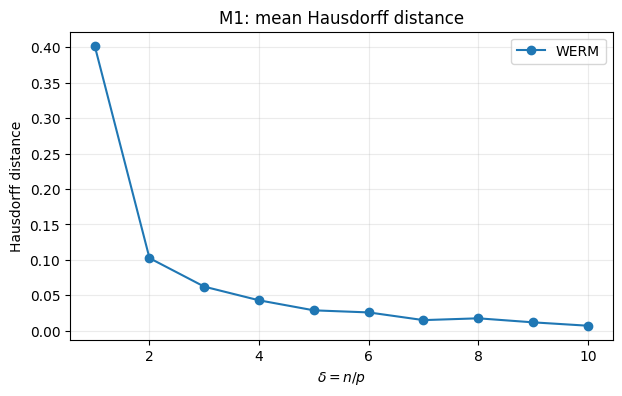

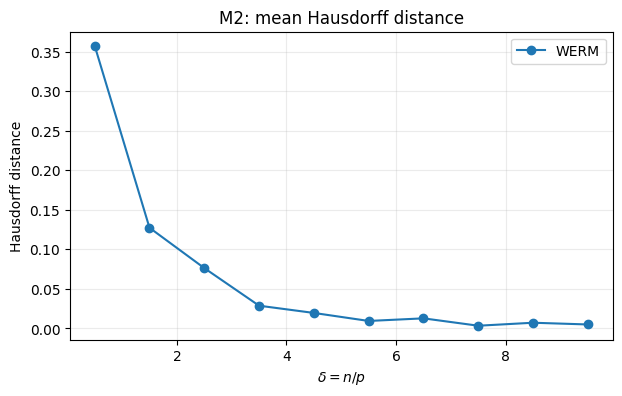

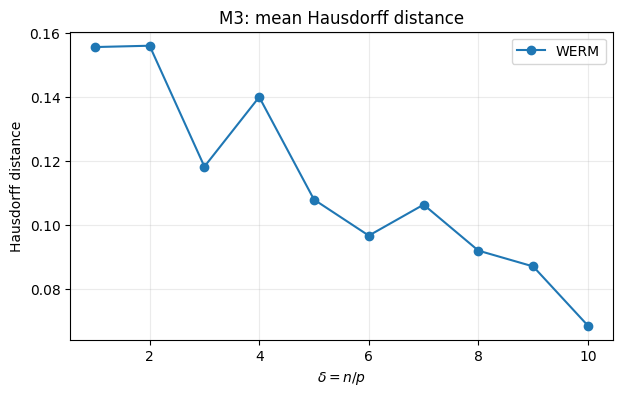

In [5]:
import matplotlib.pyplot as plt

for experiment_name in ("M1", "M2", "M3"):
    fig, ax = plot_hausdorff_summary(all_summary_rows, experiment_name)
    fig.savefig(
        OUTPUT_DIR / f"{experiment_name.lower()}_hausdorff.png", dpi=200, bbox_inches="tight"
    )
    plt.show()

## Unknown number of change points

This section runs the unknown number of change points analogues of M1, M2, and M3. It uses the `...CV` estimators in `weightederm`, and for M1 and M2 it runs `McScan` in automatic mode when `INCLUDE_MCSCAN = True`.

The trial-level CSVs in this section include `predicted_num_chgpts`. The summary rows include `mean_predicted_num_chgpts`, `median_predicted_num_chgpts`, `num_infinite_hausdorff`, `num_nan_hausdorff`, and `num_finite_hausdorff` so it is easier to see why a `mean_hausdorff` is `NaN`.

In [6]:
all_unknown_trial_rows = []
all_unknown_summary_rows = []

for experiment_name in ("M1", "M2", "M3"):
    trial_rows, summary_rows = run_benchmark_unknown(
        specs[experiment_name],
        num_trials=NUM_TRIALS,
        include_mcscan=INCLUDE_MCSCAN,
        base_seed=BASE_SEED,
        n_jobs=N_JOBS,
    )
    all_unknown_trial_rows.extend(trial_rows)
    all_unknown_summary_rows.extend(summary_rows)
    write_rows_to_csv(trial_rows, OUTPUT_DIR / f"{experiment_name.lower()}_unknown_trial_rows.csv")
    write_rows_to_csv(
        summary_rows, OUTPUT_DIR / f"{experiment_name.lower()}_unknown_summary_rows.csv"
    )
    print(experiment_name)
    for row in summary_rows:
        print(row)
    print()

write_rows_to_csv(all_unknown_trial_rows, OUTPUT_DIR / "all_unknown_trial_rows.csv")
write_rows_to_csv(all_unknown_summary_rows, OUTPUT_DIR / "all_unknown_summary_rows.csv")
OUTPUT_DIR

/scratch/ga442/weightederm/src/weightederm/_benchmark_examples.py:456: RuntimeWarning: M1 WERM at delta_ratio=2.0 predicted zero changepoints across all trials, so mean_hausdorff and median_hausdorff are NaN after reference-style inf filtering.
  return rows, summarize_trial_rows(rows)
/scratch/ga442/weightederm/src/weightederm/_benchmark_examples.py:456: RuntimeWarning: M1 WERM at delta_ratio=3.0 predicted zero changepoints across all trials, so mean_hausdorff and median_hausdorff are NaN after reference-style inf filtering.
  return rows, summarize_trial_rows(rows)
/scratch/ga442/weightederm/src/weightederm/_benchmark_examples.py:456: RuntimeWarning: M1 WERM at delta_ratio=4.0 predicted zero changepoints across all trials, so mean_hausdorff and median_hausdorff are NaN after reference-style inf filtering.
  return rows, summarize_trial_rows(rows)
/scratch/ga442/weightederm/src/weightederm/_benchmark_examples.py:456: RuntimeWarning: M1 WERM at delta_ratio=5.0 predicted zero changepoin

M1
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 1.0, 'mean_hausdorff': 0.4541666666666666, 'median_hausdorff': 0.4625, 'p25_hausdorff': 0.35624999999999996, 'p75_hausdorff': 0.55875, 'num_trials': 30, 'mean_predicted_num_chgpts': 1.3333333333333333, 'median_predicted_num_chgpts': 1.0, 'p25_predicted_num_chgpts': 1.0, 'p75_predicted_num_chgpts': 2.0, 'num_infinite_hausdorff': 0, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 30}
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 2.0, 'mean_hausdorff': nan, 'median_hausdorff': nan, 'p25_hausdorff': nan, 'p75_hausdorff': nan, 'num_trials': 30, 'mean_predicted_num_chgpts': 0.0, 'median_predicted_num_chgpts': 0.0, 'p25_predicted_num_chgpts': 0.0, 'p75_predicted_num_chgpts': 0.0, 'num_infinite_hausdorff': 30, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 0}
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 3.0, 'mean_hausdorff': nan, 'median_hausdorff': nan, 'p25_hausdorff': nan, 'p75_hausdorff': nan, 'num_trials': 30, 'me

/scratch/ga442/weightederm/src/weightederm/_benchmark_examples.py:456: RuntimeWarning: M2 WERM at delta_ratio=1.5 predicted zero changepoints across all trials, so mean_hausdorff and median_hausdorff are NaN after reference-style inf filtering.
  return rows, summarize_trial_rows(rows)
/scratch/ga442/weightederm/src/weightederm/_benchmark_examples.py:456: RuntimeWarning: M2 WERM at delta_ratio=2.5 predicted zero changepoints across all trials, so mean_hausdorff and median_hausdorff are NaN after reference-style inf filtering.
  return rows, summarize_trial_rows(rows)


M2
{'experiment': 'M2', 'method': 'WERM', 'delta_ratio': 0.5, 'mean_hausdorff': 0.3668, 'median_hausdorff': 0.37, 'p25_hausdorff': 0.33, 'p75_hausdorff': 0.39, 'num_trials': 30, 'mean_predicted_num_chgpts': 1.8, 'median_predicted_num_chgpts': 2.0, 'p25_predicted_num_chgpts': 1.0, 'p75_predicted_num_chgpts': 3.0, 'num_infinite_hausdorff': 5, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 25}
{'experiment': 'M2', 'method': 'WERM', 'delta_ratio': 1.5, 'mean_hausdorff': nan, 'median_hausdorff': nan, 'p25_hausdorff': nan, 'p75_hausdorff': nan, 'num_trials': 30, 'mean_predicted_num_chgpts': 0.0, 'median_predicted_num_chgpts': 0.0, 'p25_predicted_num_chgpts': 0.0, 'p75_predicted_num_chgpts': 0.0, 'num_infinite_hausdorff': 30, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 0}
{'experiment': 'M2', 'method': 'WERM', 'delta_ratio': 2.5, 'mean_hausdorff': nan, 'median_hausdorff': nan, 'p25_hausdorff': nan, 'p75_hausdorff': nan, 'num_trials': 30, 'mean_predicted_num_chgpts': 0.0, 'median_predicte

PosixPath('/scratch/ga442/weightederm/notebooks/results/reference_like_m123')

In [7]:
unknown_summary_view = [
    {
        "experiment": row["experiment"],
        "method": row["method"],
        "delta_ratio": row["delta_ratio"],
        "mean_hausdorff": row["mean_hausdorff"],
        "mean_predicted_num_chgpts": row["mean_predicted_num_chgpts"],
        "median_predicted_num_chgpts": row["median_predicted_num_chgpts"],
        "num_finite_hausdorff": row["num_finite_hausdorff"],
        "num_infinite_hausdorff": row["num_infinite_hausdorff"],
        "num_nan_hausdorff": row["num_nan_hausdorff"],
    }
    for row in all_unknown_summary_rows
]
unknown_summary_view

[{'experiment': 'M1',
  'method': 'WERM',
  'delta_ratio': 1.0,
  'mean_hausdorff': 0.4541666666666666,
  'mean_predicted_num_chgpts': 1.3333333333333333,
  'median_predicted_num_chgpts': 1.0,
  'num_finite_hausdorff': 30,
  'num_infinite_hausdorff': 0,
  'num_nan_hausdorff': 0},
 {'experiment': 'M1',
  'method': 'WERM',
  'delta_ratio': 2.0,
  'mean_hausdorff': nan,
  'mean_predicted_num_chgpts': 0.0,
  'median_predicted_num_chgpts': 0.0,
  'num_finite_hausdorff': 0,
  'num_infinite_hausdorff': 30,
  'num_nan_hausdorff': 0},
 {'experiment': 'M1',
  'method': 'WERM',
  'delta_ratio': 3.0,
  'mean_hausdorff': nan,
  'mean_predicted_num_chgpts': 0.0,
  'median_predicted_num_chgpts': 0.0,
  'num_finite_hausdorff': 0,
  'num_infinite_hausdorff': 30,
  'num_nan_hausdorff': 0},
 {'experiment': 'M1',
  'method': 'WERM',
  'delta_ratio': 4.0,
  'mean_hausdorff': nan,
  'mean_predicted_num_chgpts': 0.0,
  'median_predicted_num_chgpts': 0.0,
  'num_finite_hausdorff': 0,
  'num_infinite_hausdorff

In [8]:
unknown_nan_rows = [row for row in all_unknown_summary_rows if np.isnan(row["mean_hausdorff"])]

if unknown_nan_rows:
    print("Warning: some unknown-count summary groups have NaN mean_hausdorff.")
    print(
        "This usually means either all trials predicted zero changepoints "
        "(so the raw trial Hausdorff values were inf and then ignored in the "
        "reference-style average) or all trials failed."
    )
    for row in unknown_nan_rows:
        print(
            {
                "experiment": row["experiment"],
                "method": row["method"],
                "delta_ratio": row["delta_ratio"],
                "mean_predicted_num_chgpts": row["mean_predicted_num_chgpts"],
                "num_infinite_hausdorff": row["num_infinite_hausdorff"],
                "num_nan_hausdorff": row["num_nan_hausdorff"],
                "num_finite_hausdorff": row["num_finite_hausdorff"],
            }
        )
else:
    print("All unknown-count summary groups have at least one finite Hausdorff value.")

This usually means either all trials predicted zero changepoints (so the raw trial Hausdorff values were inf and then ignored in the reference-style average) or all trials failed.
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 2.0, 'mean_predicted_num_chgpts': 0.0, 'num_infinite_hausdorff': 30, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 0}
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 3.0, 'mean_predicted_num_chgpts': 0.0, 'num_infinite_hausdorff': 30, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 0}
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 4.0, 'mean_predicted_num_chgpts': 0.0, 'num_infinite_hausdorff': 30, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 0}
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 5.0, 'mean_predicted_num_chgpts': 0.0, 'num_infinite_hausdorff': 30, 'num_nan_hausdorff': 0, 'num_finite_hausdorff': 0}
{'experiment': 'M1', 'method': 'WERM', 'delta_ratio': 6.0, 'mean_predicted_num_chgpts': 0.0, 'num_infinite_hausdorff': 30, '

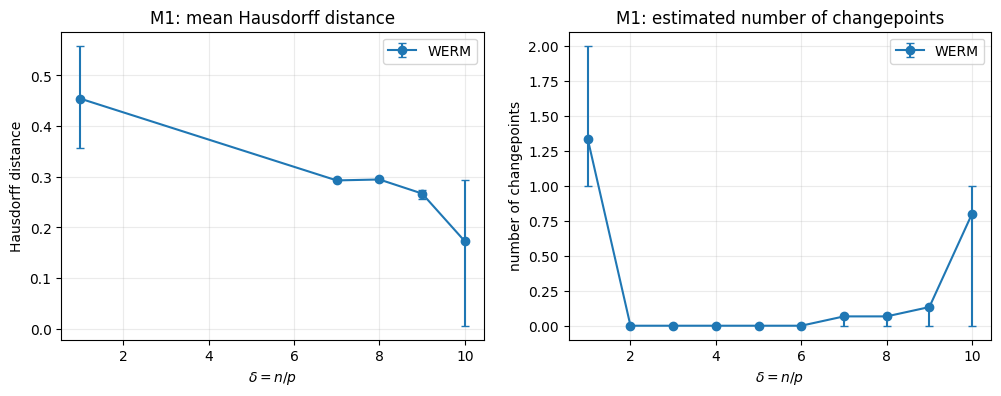

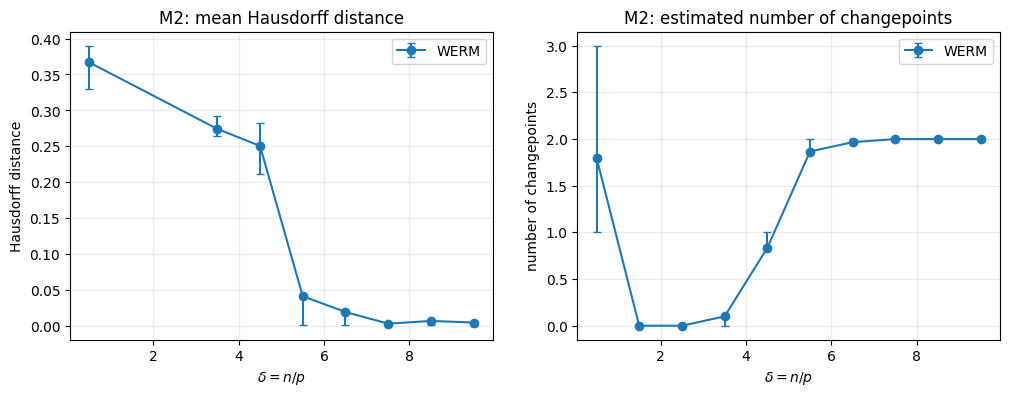

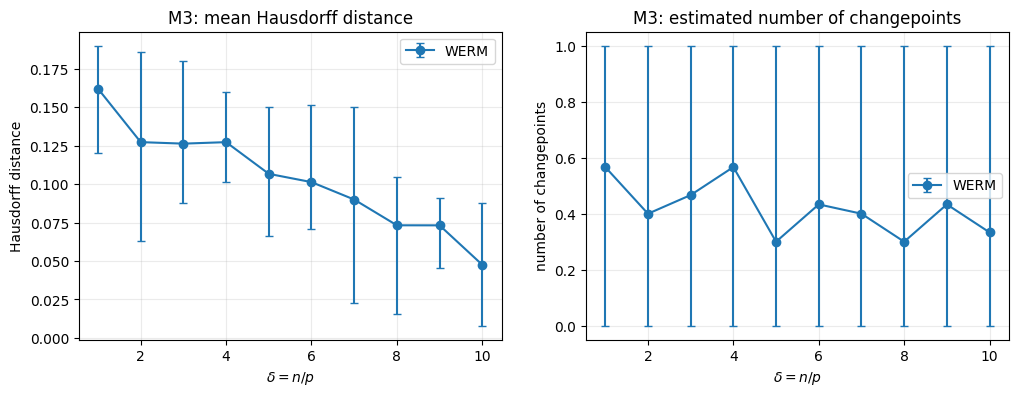

In [9]:
import matplotlib.pyplot as plt

for experiment_name in ("M1", "M2", "M3"):
    fig, axes = plot_hausdorff_summary_with_percentiles(all_unknown_summary_rows, experiment_name)
    fig.savefig(
        OUTPUT_DIR / f"{experiment_name.lower()}_unknown_hausdorff.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

## CV loss-mode comparisons

These quick comparison cells illustrate the `use_base_loss_for_cv` flag. When `False`, least-squares and Huber CV default to absolute-error segment fitting/scoring; when `True`, they use the estimator base loss instead. Logistic CV already defaults to logistic loss, so the two modes are expected to agree there unless a custom `m_scorer` is supplied.

In [10]:
m1_trial = simulate_trial(specs["M1"], delta_ratio=8.0, seed=BASE_SEED)

m1_cv_default = WERMLeastSquaresCV(
    max_num_chgpts=specs["M1"].num_signals - 1,
    delta=max(1, int(m1_trial.X_fit.shape[0] * specs["M1"].delta_fraction)),
    search_method="efficient",
    cv=5,
    fit_intercept=False,
    use_base_loss_for_cv=False,
)
m1_cv_base = WERMLeastSquaresCV(
    max_num_chgpts=specs["M1"].num_signals - 1,
    delta=max(1, int(m1_trial.X_fit.shape[0] * specs["M1"].delta_fraction)),
    search_method="efficient",
    cv=5,
    fit_intercept=False,
    use_base_loss_for_cv=True,
)

m1_cv_default.fit(m1_trial.X_fit, m1_trial.y_fit)
m1_cv_base.fit(m1_trial.X_fit, m1_trial.y_fit)

{
    "default_absolute_cv": {
        "best_num_chgpts": m1_cv_default.best_num_chgpts_,
        "best_score": m1_cv_default.best_score_,
    },
    "base_squared_cv": {
        "best_num_chgpts": m1_cv_base.best_num_chgpts_,
        "best_score": m1_cv_base.best_score_,
    },
}

{'default_absolute_cv': {'best_num_chgpts': 0,
  'best_score': 256.4486372559301},
 'base_squared_cv': {'best_num_chgpts': 0, 'best_score': 298.6789026333008}}

In [11]:
m3_trial = simulate_trial(specs["M3"], delta_ratio=4.0, seed=BASE_SEED)

m3_cv_default = WERMLogisticCV(
    max_num_chgpts=specs["M3"].num_signals - 1,
    delta=max(1, int(m3_trial.X_fit.shape[0] * specs["M3"].delta_fraction)),
    search_method="efficient",
    cv=5,
    fit_intercept=False,
    max_iter=500,
    tol=1e-6,
    use_base_loss_for_cv=False,
)
m3_cv_base = WERMLogisticCV(
    max_num_chgpts=specs["M3"].num_signals - 1,
    delta=max(1, int(m3_trial.X_fit.shape[0] * specs["M3"].delta_fraction)),
    search_method="efficient",
    cv=5,
    fit_intercept=False,
    max_iter=500,
    tol=1e-6,
    use_base_loss_for_cv=True,
)

m3_cv_default.fit(m3_trial.X_fit, m3_trial.y_fit)
m3_cv_base.fit(m3_trial.X_fit, m3_trial.y_fit)

{
    "default_logistic_cv": {
        "best_num_chgpts": m3_cv_default.best_num_chgpts_,
        "best_score": m3_cv_default.best_score_,
    },
    "explicit_base_logistic_cv": {
        "best_num_chgpts": m3_cv_base.best_num_chgpts_,
        "best_score": m3_cv_base.best_score_,
    },
}

{'default_logistic_cv': {'best_num_chgpts': 1,
  'best_score': 110.56633785787896},
 'explicit_base_logistic_cv': {'best_num_chgpts': 1,
  'best_score': 110.56633785787896}}

## Saved outputs

This notebook writes:

- fixed-known-changepoint per-experiment trial-level CSVs
- fixed-known-changepoint per-experiment summary CSVs
- combined fixed-known-changepoint trial/summary CSVs
- unknown-changepoint per-experiment trial-level CSVs, including `predicted_num_chgpts`
- unknown-changepoint per-experiment summary CSVs, including predicted-count and finite/non-finite Hausdorff summaries
- combined unknown-changepoint trial/summary CSVs
- one normalized Hausdorff plot per experiment for each setting

under `notebooks/results/reference_like_m123/`.

## Load saved results and plot

These cells reload the CSVs written above so the plots can be reproduced without re-running the experiments.

In [12]:
import csv

def load_summary_csv(path):
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        rows = []
        for row in reader:
            rows.append({
                "experiment": row["experiment"],
                "method": row["method"],
                "delta_ratio": float(row["delta_ratio"]),
                "mean_hausdorff": float(row["mean_hausdorff"]),
                "median_hausdorff": float(row["median_hausdorff"]),
                "p25_hausdorff": float(row["p25_hausdorff"]),
                "p75_hausdorff": float(row["p75_hausdorff"]),
                "num_trials": int(row["num_trials"]),
                "mean_predicted_num_chgpts": float(row["mean_predicted_num_chgpts"]),
                "median_predicted_num_chgpts": float(row["median_predicted_num_chgpts"]),
                "p25_predicted_num_chgpts": float(row["p25_predicted_num_chgpts"]),
                "p75_predicted_num_chgpts": float(row["p75_predicted_num_chgpts"]),
                "num_infinite_hausdorff": int(row["num_infinite_hausdorff"]),
                "num_nan_hausdorff": int(row["num_nan_hausdorff"]),
                "num_finite_hausdorff": int(row["num_finite_hausdorff"]),
            })
        return rows

saved_summary_rows = load_summary_csv(OUTPUT_DIR / "all_summary_rows.csv")
saved_unknown_summary_rows = load_summary_csv(OUTPUT_DIR / "all_unknown_summary_rows.csv")
print(f"Loaded {len(saved_summary_rows)} fixed-chgpts summary rows")
print(f"Loaded {len(saved_unknown_summary_rows)} unknown-chgpts summary rows")

Loaded 30 fixed-chgpts summary rows
Loaded 30 unknown-chgpts summary rows


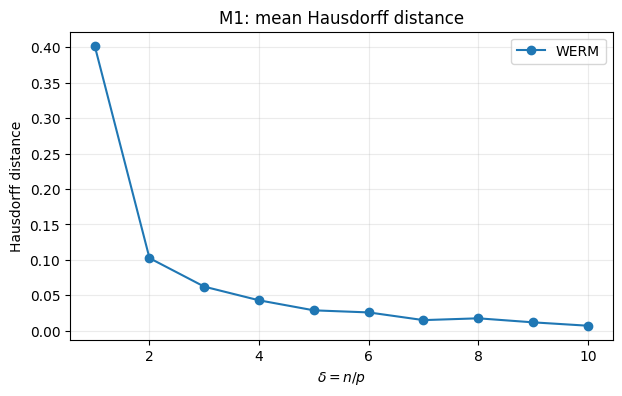

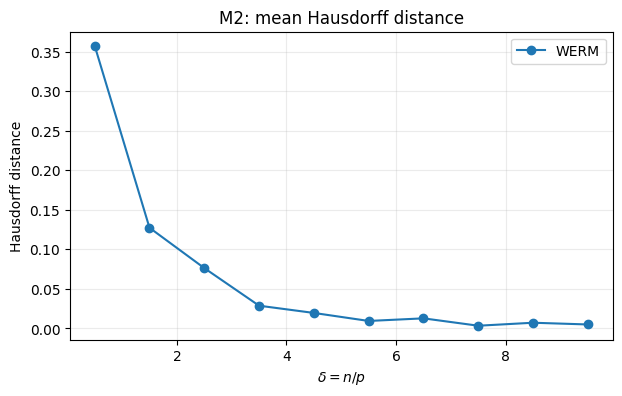

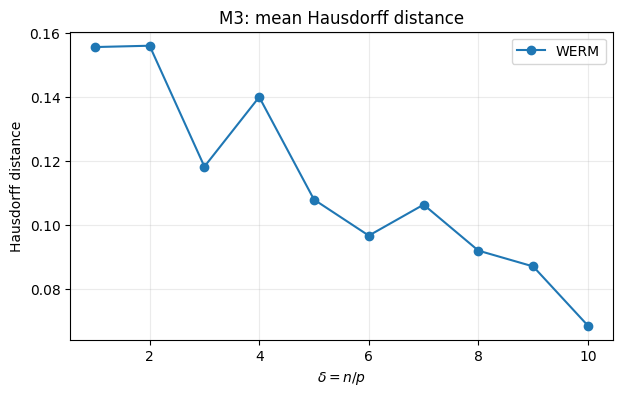

In [13]:
import matplotlib.pyplot as plt

# Fixed (known) changepoint results — mean Hausdorff only
for experiment_name in ("M1", "M2", "M3"):
    fig, ax = plot_hausdorff_summary(saved_summary_rows, experiment_name)
    plt.show()

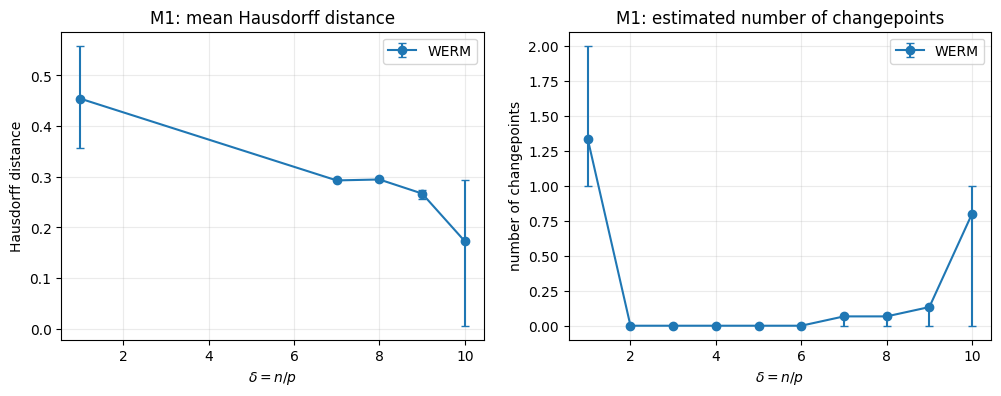

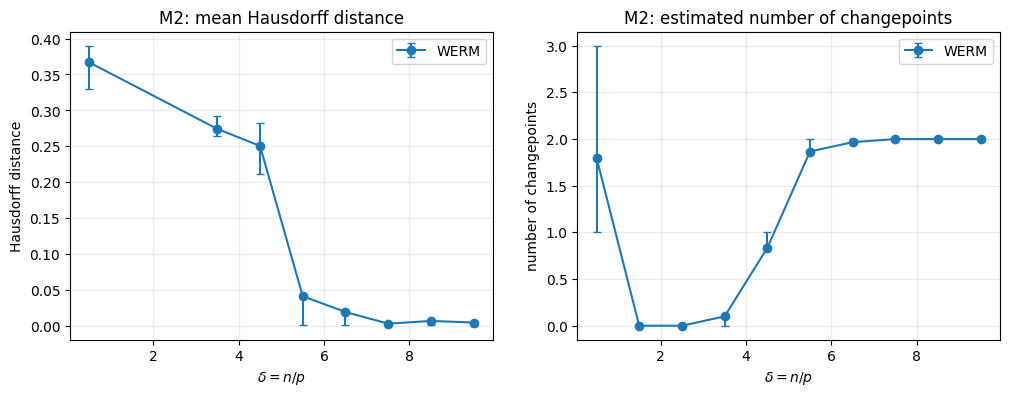

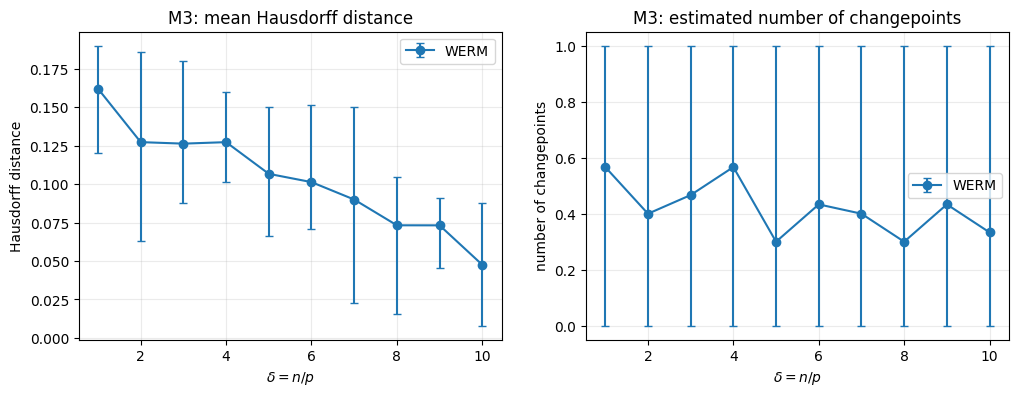

In [14]:
# Unknown changepoint results — Hausdorff with IQR error bars + estimated count
for experiment_name in ("M1", "M2", "M3"):
    fig, axes = plot_hausdorff_summary_with_percentiles(saved_unknown_summary_rows, experiment_name)
    plt.show()